### EDA
### 1. 특성(feature) 파악
### 2. 결측치와 이상치 확인 및 처리
### 3. 특성간 상관관계 분석 => 특징(시각화)
### 3+@. feature engineering(컬럼 추가 및 가공 삭제)
### 4. 인사이트 도출


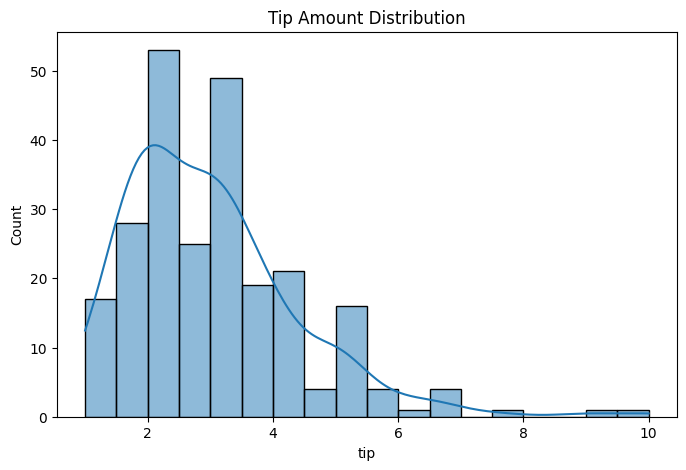

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 샘플 데이터 로드
df = sns.load_dataset('tips')

plt.figure(figsize=(8,5))
sns.histplot(df['tip'],kde=True)
plt.title('Tip Amount Distribution')
plt.show()


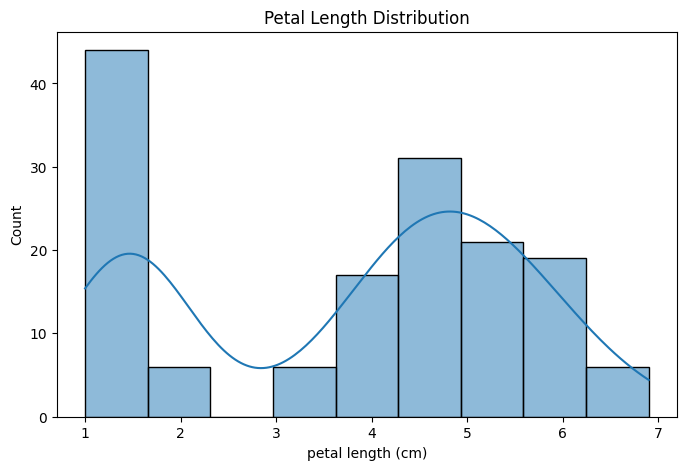

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
import pandas as pd

# Iris 데이터셋 로드 및 DataFrame 변환
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target

# 꽃잎 길이에 대한 히스토그램
plt.figure(figsize=(8, 5))
sns.histplot(df['petal length (cm)'], kde=True)
plt.title('Petal Length Distribution')
plt.show()


<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Playdata\AppData\Local\Temp\ipykernel_10692\3824231655.py:6: SyntaxWarning: invalid escape sequence '\s'
  , sep="\s+" # 공백기준으로 데이터 읽기
C:\Users\Playdata\AppData\Local\Temp\ipykernel_10692\3824231655.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  boston_df['CRIM'].fillna(boston_df['CRIM'].mean(), inplace=True)


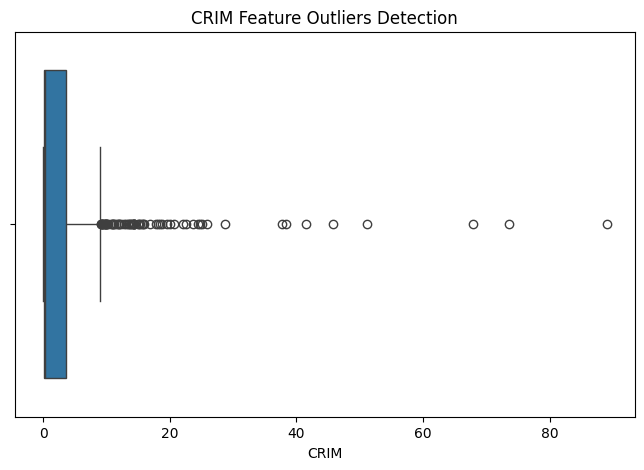

In [11]:
import numpy as np
import pandas as pd

data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url
                     , sep="\s+" # 공백기준으로 데이터 읽기
                     , skiprows=22 #앞22줄 스킵
                     , header=None) # 헤더 없음
data = np.hstack([raw_df.values[::2, :]
                  , raw_df.values[1::2, :3]])

column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
boston_df = pd.DataFrame(data, columns=column_names)

# 결측값 추가 (예시용)
boston_df.loc[5:10, 'CRIM'] = np.nan

# 결측값 처리: 평균값으로 대체
boston_df['CRIM'].fillna(boston_df['CRIM'].mean(), inplace=True)

# 이상치 탐지: 박스플롯으로 시각화
plt.figure(figsize=(8, 5))
sns.boxplot(x=boston_df['CRIM'])
plt.title('CRIM Feature Outliers Detection')
plt.show()

In [13]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# 스케일링: 표준화
scaler = StandardScaler()
boston_df[['CRIM', 'ZN']] = scaler.fit_transform(boston_df[['CRIM', 'ZN']])

# 정규화
scaler = MinMaxScaler()
boston_df[['AGE', 'TAX']] = scaler.fit_transform(boston_df[['AGE', 'TAX']])

print(boston_df)

         CRIM        ZN  INDUS  CHAS    NOX     RM       AGE     DIS  RAD  \
0   -0.425042  0.284830   2.31   0.0  0.538  6.575  0.641607  4.0900  1.0   
1   -0.422597 -0.487722   7.07   0.0  0.469  6.421  0.782698  4.9671  2.0   
2   -0.422599 -0.487722   7.07   0.0  0.469  7.185  0.599382  4.9671  2.0   
3   -0.422007 -0.487722   2.18   0.0  0.458  6.998  0.441813  6.0622  3.0   
4   -0.417735 -0.487722   2.18   0.0  0.458  7.147  0.528321  6.0622  3.0   
..        ...       ...    ...   ...    ...    ...       ...     ...  ...   
501 -0.418482 -0.487722  11.93   0.0  0.573  6.593  0.681771  2.4786  1.0   
502 -0.420505 -0.487722  11.93   0.0  0.573  6.120  0.760041  2.2875  1.0   
503 -0.418700 -0.487722  11.93   0.0  0.573  6.976  0.907312  2.1675  1.0   
504 -0.413012 -0.487722  11.93   0.0  0.573  6.794  0.889804  2.3889  1.0   
505 -0.420255 -0.487722  11.93   0.0  0.573  6.030  0.802266  2.5050  1.0   

          TAX  PTRATIO       B  LSTAT  MEDV  
0    0.208015     15.3  396.9